# Library project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3


### Reading data

##### Reading Database

In [2]:
conn=sqlite3.connect("download")

In [3]:
members=pd.read_sql("select * from members",conn)
members

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05
1,1002,Fares,Saleh,9.0,Maadi,Active,NaN
2,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23
3,1004,Fares,Wahba,7.0,Maadi,inactive,2024-10-09
4,1005,Youssef,Halim,9.0,Maadi,Active,2024-05-05
...,...,...,...,...,...,...,...
75,1076,Dina,Wahba,7.0,Shubra,Active,2025-12-13
76,1077,Lina,Rashad,6.0,Shubra,Active,2023-07-08
77,1078,Habiba,Osman,7.0,Shubra,INACTIVE,2023-08-05
78,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27


In [4]:
books=pd.read_sql_query("SELECT * FROM books",conn)
books

,book_id,title,author
0,501,The Silver Kite,Amina Darwish
1,502,Desert Compass,Amina Darwish
2,503,The Lantern Maker,Adel Roushdy
3,504,Rooftop Astronomers,Adel Roushdy
4,505,Letters to the Nile,Aya Hafez
5,506,The Paper Boat Club,Aya Hafez
6,507,Fossils and Fireflies,Dalia Serry
7,508,The Quiet Observatory,Dalia Serry
8,509,Marbles and Mirrors,Diaa Sultan
9,510,The Missing Metronome,Diaa Sultan


In [5]:
checkouts=pd.read_sql_query("SELECT * FROM checkouts",conn)
checkouts

,checkout_id,member_id,book_id,checkout_date,return_date
0,9263,1047,517,2024-10-21,2024-11-07
1,9340,1072,513,2025-08-24,2025-09-01
2,9231,1053,523,2024-02-04,2024-02-16
3,9129,1032,513,2025-06-21,2025-06-29
4,9370,1079,511,2025-11-11,2025-12-03
...,...,...,...,...,...
386,9232,1044,513,2025-05-26,2025-06-11
387,9084,1008,511,2024-06-27,2024-07-22
388,9116,1024,519,2025-01-10,2025-02-09
389,9352,1076,501,2025-02-02,NaN


##### Reading jason file

In [6]:
book_details=pd.read_json("download (1)")
book_details

,book_id,genre,pages,publication_year,publisher
0,501,Adventure,128,2017.0,Nile Press
1,502,Adventure,109,2018.0,Delta House
2,503,Historical,259,NaN,Nile Press
3,504,Science,319,2009.0,Cairo Young Readers
4,505,Historical,216,2024.0,Oasis Books
5,506,Friendship,183,NaN,Nile Press
6,507,Science,160,2024.0,Nile Press
7,508,Science,306,2011.0,Oasis Books
8,509,Mystery,221,2011.0,Nile Press
9,510,Mystery,134,2013.0,Cairo Young Readers


##### Reading html file

In [7]:
summer_checkouts=pd.read_html("download (2).html")[0]
summer_checkouts

,Member ID,Book ID,Checkout Date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07
5,1009,503,2025-07-09
6,1063,522,2025-07-07
7,1022,511,2025-07-12
8,1029,523,2025-07-09
9,1201,509,2025-07-10


In [8]:
summer_checkouts.columns=["member_id","book_id","checkout_date"]
summer_checkouts

,member_id,book_id,checkout_date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07
5,1009,503,2025-07-09
6,1063,522,2025-07-07
7,1022,511,2025-07-12
8,1029,523,2025-07-09
9,1201,509,2025-07-10


### Final dataset

###### all checkouts

In [9]:
summer_checkouts_copy = summer_checkouts.copy()
summer_checkouts_copy["checkout_id"] = pd.NA
summer_checkouts_copy["return_date"] = pd.NaT

all_checkouts = pd.concat(
    [checkouts, summer_checkouts_copy],
    ignore_index=True
)

###### merge members data

In [10]:
merged_members = all_checkouts.merge(
    members,
    on="member_id",
    how="left"
)

###### merge basic book information

In [11]:
merged_book = merged_members.merge(
    books,
    on="book_id",
    how="left"
)

###### merge detailed book information

In [12]:
library_data = merged_book.merge(
    book_details,
    on="book_id",
    how="left"
)

In [13]:
library_data

,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,title,author,genre,pages,publication_year,publisher
0,9263,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,Shadows on the Corniche,Hani Nagati,Mystery,338,2015.0,Delta House
1,9340,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
2,9231,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books
3,9129,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
4,9370,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,Winter in Alexandria,Farida Anwar,Historical,117,2016.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,<NA>,1003,501,2025-07-08,NaT,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
413,<NA>,1017,507,2025-07-11,NaT,Adam,Badr,9.0,Maadi,Active,2025-07-12,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
414,<NA>,1061,504,2025-07-06,NaT,Ziad,Fahmy,9.0,zamalek,Inactive,2023-04-27,Rooftop Astronomers,Adel Roushdy,Science,319,2009.0,Cairo Young Readers
415,<NA>,1201,523,2025-07-08,NaT,NaN,NaN,NaN,NaN,NaN,NaN,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books


### Explore data

In [14]:
library_data=library_data[["member_id","first_name","last_name","grade","join_date","checkout_id","checkout_date","return_date","membership_status",
                      "neighborhood","book_id","title","author","genre","pages","publication_year","publisher"]]
library_data

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
0,1047,Sara,Rashad,NaN,2024-06-25,9263,2024-10-21,2024-11-07,Inactive,Heliopolis,517,Shadows on the Corniche,Hani Nagati,Mystery,338,2015.0,Delta House
1,1072,Seif,Zaki,9.0,2025-10-21,9340,2025-08-24,2025-09-01,Active,Zamalek,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
2,1053,Adam,Shafik,9.0,2024-01-03,9231,2024-02-04,2024-02-16,Active,Heliopolis,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books
3,1032,Nada,Zaki,7.0,2025-10-19,9129,2025-06-21,2025-06-29,Active,Nasr City,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
4,1079,Rana,Osman,8.0,2024-10-27,9370,2025-11-11,2025-12-03,Active,Shubra,511,Winter in Alexandria,Farida Anwar,Historical,117,2016.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1003,Bassel,Hegazy,6.0,2025-04-23,<NA>,2025-07-08,NaT,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
413,1017,Adam,Badr,9.0,2025-07-12,<NA>,2025-07-11,NaT,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
414,1061,Ziad,Fahmy,9.0,2023-04-27,<NA>,2025-07-06,NaT,Inactive,zamalek,504,Rooftop Astronomers,Adel Roushdy,Science,319,2009.0,Cairo Young Readers
415,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-08,NaT,NaN,NaN,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books


In [15]:
library_data.head()

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
0,1047,Sara,Rashad,NaN,2024-06-25,9263,2024-10-21,2024-11-07,Inactive,Heliopolis,517,Shadows on the Corniche,Hani Nagati,Mystery,338,2015.0,Delta House
1,1072,Seif,Zaki,9.0,2025-10-21,9340,2025-08-24,2025-09-01,Active,Zamalek,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
2,1053,Adam,Shafik,9.0,2024-01-03,9231,2024-02-04,2024-02-16,Active,Heliopolis,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books
3,1032,Nada,Zaki,7.0,2025-10-19,9129,2025-06-21,2025-06-29,Active,Nasr City,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
4,1079,Rana,Osman,8.0,2024-10-27,9370,2025-11-11,2025-12-03,Active,Shubra,511,Winter in Alexandria,Farida Anwar,Historical,117,2016.0,Nile Press


In [16]:
library_data.tail()

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
412,1003,Bassel,Hegazy,6.0,2025-04-23,<NA>,2025-07-08,NaT,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
413,1017,Adam,Badr,9.0,2025-07-12,<NA>,2025-07-11,NaT,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
414,1061,Ziad,Fahmy,9.0,2023-04-27,<NA>,2025-07-06,NaT,Inactive,zamalek,504,Rooftop Astronomers,Adel Roushdy,Science,319,2009.0,Cairo Young Readers
415,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-08,NaT,NaN,NaN,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books
416,1041,Nada,Rashad,7.0,2024-04-02,<NA>,2025-07-06,NaT,Active,Nasr City,512,The Cartographer's Cat,Farida Anwar,Adventure,238,2022.0,Delta House


In [17]:
library_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   member_id          417 non-null    int64  
 1   first_name         412 non-null    str    
 2   last_name          412 non-null    str    
 3   grade              376 non-null    float64
 4   join_date          406 non-null    str    
 5   checkout_id        391 non-null    object 
 6   checkout_date      417 non-null    str    
 7   return_date        326 non-null    object 
 8   membership_status  412 non-null    str    
 9   neighborhood       412 non-null    str    
 10  book_id            417 non-null    int64  
 11  title              417 non-null    str    
 12  author             417 non-null    str    
 13  genre              417 non-null    str    
 14  pages              417 non-null    int64  
 15  publication_year   382 non-null    float64
 16  publisher          417 non-null    st

In [18]:
library_data.describe()

,member_id,grade,book_id,pages,publication_year
count,417.000000,376.000000,417.000000,417.000000,382.000000
mean,1041.004796,7.577128,513.443645,202.299760,2017.426702
std,26.356925,1.154427,8.976053,73.986738,4.567214
min,1001.000000,6.000000,501.000000,104.000000,2009.000000
25%,1020.000000,7.000000,507.000000,134.000000,2014.000000
50%,1036.000000,8.000000,513.000000,160.000000,2017.000000
75%,1061.000000,9.000000,519.000000,294.000000,2021.000000
max,1201.000000,9.000000,532.000000,338.000000,2024.000000


#### check duplication

In [19]:
library_data.duplicated().sum().sum()

np.int64(8)

In [20]:
library_data[library_data.duplicated(keep=False)]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
69,1065,Adam,Fahmy,6.0,2025-07-12,9296,2024-12-15,2025-01-11,Active,Zamalek,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
73,1054,Retaj,Fahmy,6.0,2024-03-21,9280,2024-09-06,2024-09-15,Inactive,Heliopolis,517,Shadows on the Corniche,Hani Nagati,Mystery,338,2015.0,Delta House
113,1019,Mostafa,Wahba,6.0,2024-07-20,9052,2024-06-20,2024-06-29,Inactive,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
116,1024,Youssef,Hegazy,8.0,2024-01-04,9194,2024-09-17,2024-10-09,inactive,Nasr City,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
121,1034,Aya,Wahba,9.0,2025-01-22,9193,2024-09-15,2024-10-01,Active,Nasr City,519,Kites Over Cairo,Jasmine Wahdan,Friendship,157,2014.0,Nile Press
225,1065,Adam,Fahmy,6.0,2025-07-12,9296,2024-12-15,2025-01-11,Active,Zamalek,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
244,1065,Adam,Fahmy,6.0,2025-07-12,9334,2025-12-20,2026-01-05,Active,Zamalek,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
246,1034,Aya,Wahba,9.0,2025-01-22,9180,2024-07-27,2024-08-02,Active,Nasr City,529,Riddles of the Red Sea,Sara Tantawy,Mystery,298,NaN,Cairo Young Readers
278,1034,Aya,Wahba,9.0,2025-01-22,9180,2024-07-27,2024-08-02,Active,Nasr City,529,Riddles of the Red Sea,Sara Tantawy,Mystery,298,NaN,Cairo Young Readers
301,1065,Adam,Fahmy,6.0,2025-07-12,9334,2025-12-20,2026-01-05,Active,Zamalek,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press


In [21]:
library_data.groupby("checkout_id").agg({
    "member_id": "nunique",
    "book_id": "nunique"
}).sort_values("book_id", ascending=False)

,member_id,book_id
checkout_id,,
9001,1,1
9002,1,1
9003,1,1
9004,1,1
9005,1,1
...,...,...
9379,1,1
9380,1,1
9381,1,1


#### check missing values

In [22]:
library_data.isna().sum()


member_id             0
first_name            5
last_name             5
grade                41
join_date            11
checkout_id          26
checkout_date         0
return_date          91
membership_status     5
neighborhood          5
book_id               0
title                 0
author                0
genre                 0
pages                 0
publication_year     35
publisher             0
dtype: int64

In [23]:
library_data[library_data["first_name"].isna()]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
395,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-07,NaT,NaN,NaN,515,Songs of the Oasis,Hoda Bakry,Poetry,316,2022.0,Cairo Young Readers
400,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,509,Marbles and Mirrors,Diaa Sultan,Mystery,221,2011.0,Nile Press
402,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-05,NaT,NaN,NaN,526,The Clockwork Orchard,Mahmoud Rafei,Science Fiction,125,2016.0,Delta House
405,1150,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,530,The Sandstone Key,Sara Tantawy,Adventure,208,2012.0,Oasis Books
415,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-08,NaT,NaN,NaN,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books


In [24]:
library_data[library_data["join_date"].isna()]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
90,1023,Hassan,Rashad,8.0,NaN,9188,2025-05-11,2025-06-08,Inactive,Nasr City,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
199,1002,Fares,Saleh,9.0,NaN,9013,2024-02-16,2024-02-29,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
218,1039,Nada,Riad,7.0,NaN,9125,2025-06-17,NaN,active,Nasr City,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
300,1039,Nada,Riad,7.0,NaN,9138,2025-08-22,2025-08-31,active,Nasr City,516,The Beekeeper's Almanac,Hoda Bakry,Nature,241,2010.0,Nile Press
312,1002,Fares,Saleh,9.0,NaN,9095,2024-06-25,2024-07-07,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
395,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-07,NaT,NaN,NaN,515,Songs of the Oasis,Hoda Bakry,Poetry,316,2022.0,Cairo Young Readers
400,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,509,Marbles and Mirrors,Diaa Sultan,Mystery,221,2011.0,Nile Press
402,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-05,NaT,NaN,NaN,526,The Clockwork Orchard,Mahmoud Rafei,Science Fiction,125,2016.0,Delta House
404,1002,Fares,Saleh,9.0,NaN,<NA>,2025-07-08,NaT,Active,Maadi,521,A Garden of Equations,Karim Elwy,Science,211,2024.0,Cairo Young Readers
405,1150,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,530,The Sandstone Key,Sara Tantawy,Adventure,208,2012.0,Oasis Books


In [25]:
library_data[library_data.isna().any(axis=1)]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
0,1047,Sara,Rashad,NaN,2024-06-25,9263,2024-10-21,2024-11-07,Inactive,Heliopolis,517,Shadows on the Corniche,Hani Nagati,Mystery,338,2015.0,Delta House
7,1010,Nour,Nabil,6.0,2024-05-15,9012,2025-02-17,NaN,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
8,1024,Youssef,Hegazy,8.0,2024-01-04,9127,2025-06-13,NaN,inactive,Nasr City,506,The Paper Boat Club,Aya Hafez,Friendship,183,NaN,Nile Press
9,1016,Dina,Rashad,8.0,2023-04-24,9020,2024-04-15,2024-05-04,Active,Maadi,506,The Paper Boat Club,Aya Hafez,Friendship,183,NaN,Nile Press
22,1018,Ahmed,Shafik,9.0,2023-01-28,9030,2025-03-09,NaN,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1003,Bassel,Hegazy,6.0,2025-04-23,<NA>,2025-07-08,NaT,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
413,1017,Adam,Badr,9.0,2025-07-12,<NA>,2025-07-11,NaT,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
414,1061,Ziad,Fahmy,9.0,2023-04-27,<NA>,2025-07-06,NaT,Inactive,zamalek,504,Rooftop Astronomers,Adel Roushdy,Science,319,2009.0,Cairo Young Readers
415,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-08,NaT,NaN,NaN,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books


#### Check for Data Inconsistencies

In [26]:
library_data["neighborhood"].value_counts()

neighborhood
Nasr City     103
Maadi          96
Heliopolis     88
Zamalek        60
Shubra         34
Maadi          19
zamalek        10
NASR CITY       1
HELIOPOLIS      1
Name: count, dtype: int64

In [27]:
library_data["membership_status"].value_counts()

membership_status
Active      279
Inactive     55
active       46
inactive     32
Name: count, dtype: int64

In [28]:
library_data["author"].value_counts()

author
Amina Darwish     65
Dalia Serry       57
Galal Mounir      54
Jasmine Wahdan    48
Mahmoud Rafei     31
Aya Hafez         22
Diaa Sultan       20
Sara Tantawy      19
Hoda Bakry        18
Karim Elwy        17
Hani Nagati       14
Farida Anwar      14
Mona Kholoussy    11
Adel Roushdy      11
Samir Zohdy       10
Laila Shokry       6
Name: count, dtype: int64

In [29]:
library_data["genre"].value_counts()

genre
Science            114
Adventure          112
Friendship          62
Mystery             47
Historical          32
Nature              23
Science Fiction     21
Poetry               6
Name: count, dtype: int64

In [30]:
library_data["publisher"].value_counts()


publisher
Nile Press             207
Oasis Books            113
Cairo Young Readers     55
Delta House             42
Name: count, dtype: int64

##### Data quality issue

In [31]:
library_data[library_data["checkout_date"] < library_data["join_date"]]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
1,1072,Seif,Zaki,9.0,2025-10-21,9340,2025-08-24,2025-09-01,Active,Zamalek,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
3,1032,Nada,Zaki,7.0,2025-10-19,9129,2025-06-21,2025-06-29,Active,Nasr City,513,Circuits for Beginners,Galal Mounir,Science,294,2021.0,Oasis Books
11,1065,Adam,Fahmy,6.0,2025-07-12,9319,2025-02-10,2025-02-21,Active,Zamalek,515,Songs of the Oasis,Hoda Bakry,Poetry,316,2022.0,Cairo Young Readers
14,1032,Nada,Zaki,7.0,2025-10-19,9157,2024-03-04,2024-04-03,Active,Nasr City,525,Storms and Sailboats,Mahmoud Rafei,Adventure,297,2015.0,Oasis Books
15,1070,Ahmed,Zaki,9.0,2025-07-22,9383,2024-07-11,2024-07-31,Active,Zamalek,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1058,Lina,Mansour,8.0,2025-07-20,<NA>,2025-07-08,NaT,active,Heliopolis,518,The Ninth Lighthouse,Hani Nagati,Adventure,163,2011.0,Delta House
409,1012,Ali,Hegazy,7.0,2025-12-08,<NA>,2025-07-11,NaT,Active,Maadi,509,Marbles and Mirrors,Diaa Sultan,Mystery,221,2011.0,Nile Press
410,1007,Sherif,Fouad,6.0,2025-08-18,<NA>,2025-07-07,NaT,Active,Maadi,510,The Missing Metronome,Diaa Sultan,Mystery,134,2013.0,Cairo Young Readers
411,1073,Yassin,Kamel,7.0,2025-08-26,<NA>,2025-07-07,NaT,Inactive,Zamalek,530,The Sandstone Key,Sara Tantawy,Adventure,208,2012.0,Oasis Books


In [32]:
library_data[library_data["member_id"]==1201]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
400,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,509,Marbles and Mirrors,Diaa Sultan,Mystery,221,2011.0,Nile Press
415,1201,NaN,NaN,NaN,NaN,<NA>,2025-07-08,NaT,NaN,NaN,523,Footsteps in the Dust,Laila Shokry,Historical,276,2018.0,Oasis Books


In [33]:
library_data[library_data["member_id"]==1002]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
199,1002,Fares,Saleh,9.0,NaN,9013,2024-02-16,2024-02-29,Active,Maadi,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
312,1002,Fares,Saleh,9.0,NaN,9095,2024-06-25,2024-07-07,Active,Maadi,507,Fossils and Fireflies,Dalia Serry,Science,160,2024.0,Nile Press
404,1002,Fares,Saleh,9.0,NaN,<NA>,2025-07-08,NaT,Active,Maadi,521,A Garden of Equations,Karim Elwy,Science,211,2024.0,Cairo Young Readers


In [34]:
library_data[library_data["member_id"]==1039]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
218,1039,Nada,Riad,7.0,NaN,9125,2025-06-17,NaN,active,Nasr City,501,The Silver Kite,Amina Darwish,Adventure,128,2017.0,Nile Press
300,1039,Nada,Riad,7.0,NaN,9138,2025-08-22,2025-08-31,active,Nasr City,516,The Beekeeper's Almanac,Hoda Bakry,Nature,241,2010.0,Nile Press


In [35]:
library_data[library_data["member_id"]==1150]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
405,1150,NaN,NaN,NaN,NaN,<NA>,2025-07-10,NaT,NaN,NaN,530,The Sandstone Key,Sara Tantawy,Adventure,208,2012.0,Oasis Books


In [36]:
library_data[library_data["member_id"]==1104]

,member_id,first_name,last_name,grade,join_date,checkout_id,checkout_date,return_date,membership_status,neighborhood,book_id,title,author,genre,pages,publication_year,publisher
395,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-07,NaT,NaN,NaN,515,Songs of the Oasis,Hoda Bakry,Poetry,316,2022.0,Cairo Young Readers
402,1104,NaN,NaN,NaN,NaN,<NA>,2025-07-05,NaT,NaN,NaN,526,The Clockwork Orchard,Mahmoud Rafei,Science Fiction,125,2016.0,Delta House


#### Handle data issues

In [37]:
library_data = library_data.dropna(subset=["first_name", "last_name"])

In [38]:
library_data[["first_name", "last_name"]].isna().sum()

first_name    0
last_name     0
dtype: int64

##### handle incorrect data type

In [39]:
date_columns = ["checkout_date", "return_date", "join_date"]

for col in date_columns:
    library_data[col] = pd.to_datetime(library_data[col], errors="coerce")

In [40]:
library_data[date_columns].dtypes

checkout_date    datetime64[us]
return_date      datetime64[us]
join_date        datetime64[us]
dtype: object

In [41]:
id_columns = ["member_id", "checkout_id", "book_id"]

for col in id_columns:
    library_data[col] = library_data[col].astype("string")

In [42]:
library_data[id_columns].dtypes

member_id      string
checkout_id    string
book_id        string
dtype: object

In [43]:
library_data.info()

<class 'pandas.DataFrame'>
Index: 412 entries, 0 to 416
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   member_id          412 non-null    string        
 1   first_name         412 non-null    str           
 2   last_name          412 non-null    str           
 3   grade              376 non-null    float64       
 4   join_date          406 non-null    datetime64[us]
 5   checkout_id        391 non-null    string        
 6   checkout_date      412 non-null    datetime64[us]
 7   return_date        326 non-null    datetime64[us]
 8   membership_status  412 non-null    str           
 9   neighborhood       412 non-null    str           
 10  book_id            412 non-null    string        
 11  title              412 non-null    str           
 12  author             412 non-null    str           
 13  genre              412 non-null    str           
 14  pages              412 non

##### handle data Inconsistency

In [44]:
library_data["neighborhood"] = library_data["neighborhood"].str.strip().str.title()

In [45]:
library_data["neighborhood"].value_counts()

neighborhood
Maadi         115
Nasr City     104
Heliopolis     89
Zamalek        70
Shubra         34
Name: count, dtype: int64

In [46]:
library_data["membership_status"] = library_data["membership_status"].str.strip().str.title()

In [47]:
library_data["membership_status"].value_counts()

membership_status
Active      325
Inactive     87
Name: count, dtype: int64

In [48]:
library_data["grade"] = library_data["grade"].fillna(
    library_data["grade"].median()
).round().astype(int)

In [49]:
library_data.isna().sum()

member_id             0
first_name            0
last_name             0
grade                 0
join_date             6
checkout_id          21
checkout_date         0
return_date          86
membership_status     0
neighborhood          0
book_id               0
title                 0
author                0
genre                 0
pages                 0
publication_year     35
publisher             0
dtype: int64

### Data analysis and visualize

##### How does borrowing activity change over time?

In [50]:
monthly_borrowing = (
    library_data
    .groupby(library_data["checkout_date"].dt.to_period("M"))
    .size()
    .reset_index(name="borrow_count")
)
monthly_borrowing["checkout_date"] = monthly_borrowing["checkout_date"].dt.to_timestamp()
monthly_borrowing

,checkout_date,borrow_count
0,2024-01-01,14
1,2024-02-01,12
2,2024-03-01,16
3,2024-04-01,9
4,2024-05-01,7
5,2024-06-01,17
6,2024-07-01,14
7,2024-08-01,17
8,2024-09-01,16
9,2024-10-01,13


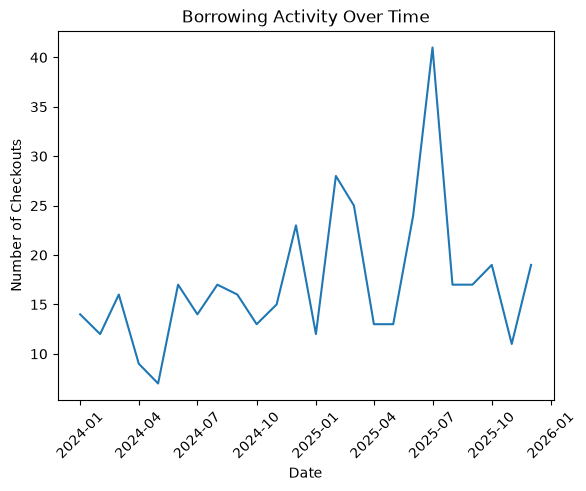

In [51]:
plt.plot(
    monthly_borrowing["checkout_date"],
    monthly_borrowing["borrow_count"]
)

plt.title("Borrowing Activity Over Time")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Number of Checkouts")

plt.show()

##### Which books and authors are the most popular?

In [52]:
popular_books = (
    library_data
    .groupby(["book_id", "title"])
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)
popular_books.head(10)

,book_id,title,borrow_count
0,501,The Silver Kite,58
6,507,Fossils and Fireflies,56
12,513,Circuits for Beginners,48
18,519,Kites Over Cairo,38
24,525,Storms and Sailboats,26
5,506,The Paper Boat Club,14
15,516,The Beekeeper's Almanac,12
28,529,Riddles of the Red Sea,12
19,520,The Copper Telescope,10
8,509,Marbles and Mirrors,10


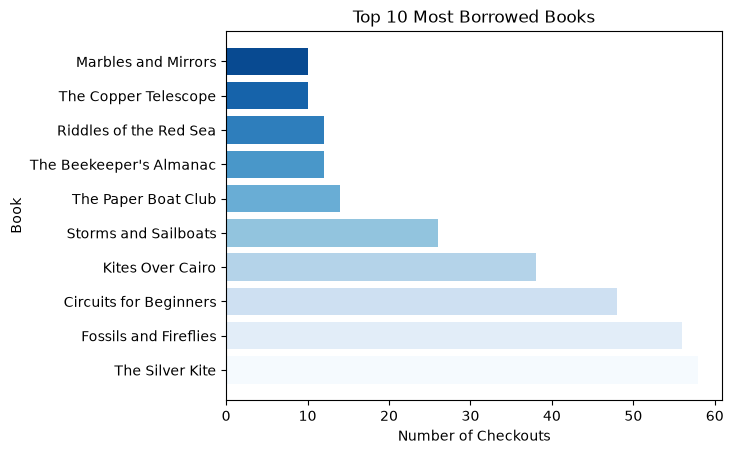

In [53]:
Top_popular_books = popular_books.head(10)
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(Top_popular_books))
)
plt.barh(
    Top_popular_books["title"],
    Top_popular_books["borrow_count"],
    color=colors
)

plt.title("Top 10 Most Borrowed Books")
plt.xlabel("Number of Checkouts")
plt.ylabel("Book")
plt.show()

In [54]:
popular_authors = (
    library_data
    .groupby("author")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)

popular_authors.head(10)

,author,borrow_count
1,Amina Darwish,65
3,Dalia Serry,57
6,Galal Mounir,54
9,Jasmine Wahdan,48
12,Mahmoud Rafei,30
2,Aya Hafez,22
4,Diaa Sultan,19
15,Sara Tantawy,18
10,Karim Elwy,17
8,Hoda Bakry,17


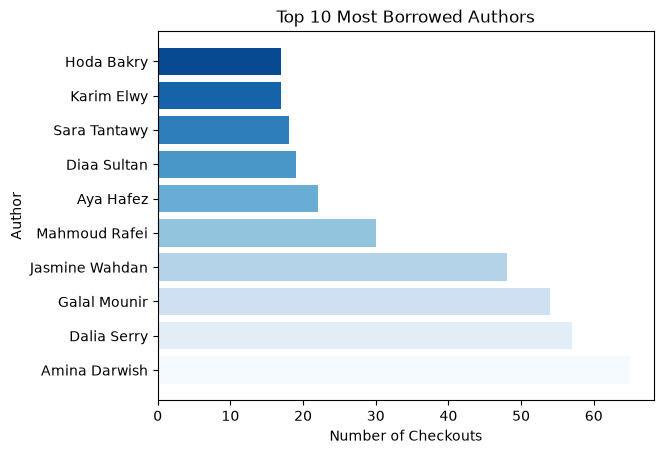

In [55]:
Top_popular_authors = popular_authors.head(10)
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(Top_popular_authors))
)
plt.barh(
    Top_popular_authors["author"],
    Top_popular_authors["borrow_count"],
    color=colors
)

plt.title("Top 10 Most Borrowed Authors")
plt.xlabel("Number of Checkouts")
plt.ylabel("Author")
plt.show()

##### Which genres are most popular, and how does genre preference differ across member groups?

In [56]:
genre_borrowing = (
    library_data
    .groupby("genre")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)

genre_borrowing

,genre,borrow_count
6,Science,114
0,Adventure,111
1,Friendship,62
3,Mystery,46
2,Historical,31
4,Nature,23
7,Science Fiction,20
5,Poetry,5


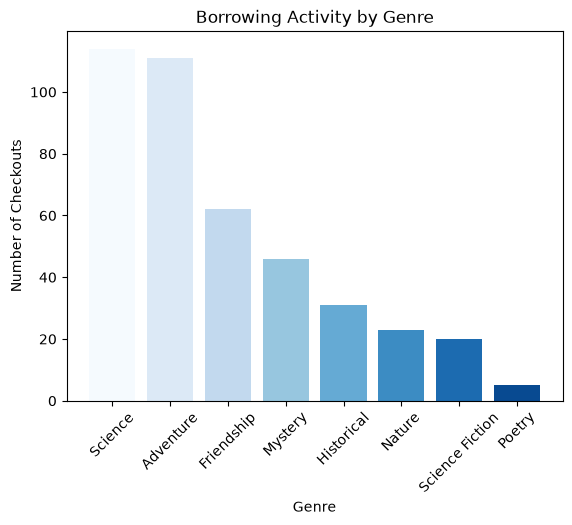

In [57]:
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(genre_borrowing))
)
plt.bar(
    genre_borrowing["genre"],
    genre_borrowing["borrow_count"],
    color=colors
)

plt.title("Borrowing Activity by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Checkouts")
plt.xticks(rotation=45)
plt.show()

In [58]:
genre_by_grade = pd.crosstab(
    library_data["grade"],
    library_data["genre"]
)

genre_by_grade

genre,Adventure,Friendship,Historical,Mystery,Nature,Poetry,Science,Science Fiction
grade,,,,,,,,
6,19,14,7,10,4,3,26,8
7,25,14,5,10,6,1,27,2
8,40,16,8,10,7,0,31,6
9,27,18,11,16,6,1,30,4


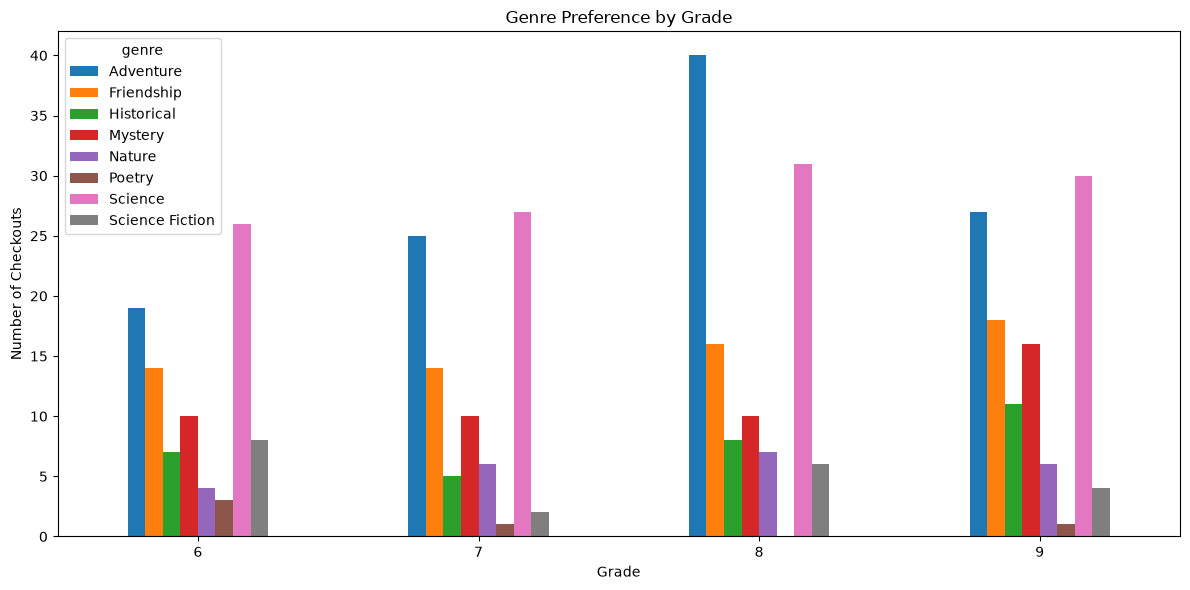

In [59]:
genre_by_grade.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Genre Preference by Grade")
plt.xlabel("Grade")
plt.ylabel("Number of Checkouts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Who are the most active library members?

In [60]:
active_members=(
    library_data
    .groupby("member_id")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)
member_names = (
    library_data[
        ["member_id", "first_name", "last_name"]
    ]
    .drop_duplicates("member_id")
)

Top_active_members = (
    active_members
    .head(10)
    .merge(member_names, on="member_id", how="left")
)

Top_active_members["full_name"] = (
    Top_active_members["first_name"] + " " +
    Top_active_members["last_name"]
)

Top_active_members = Top_active_members.sort_values("borrow_count")
Top_active_members

,member_id,borrow_count,first_name,last_name,full_name
9,1047,16,Sara,Rashad,Sara Rashad
8,1030,16,Reem,Osman,Reem Osman
6,1018,17,Ahmed,Shafik,Ahmed Shafik
7,1024,17,Youssef,Hegazy,Youssef Hegazy
4,1027,18,Mostafa,Fouad,Mostafa Fouad
5,1010,18,Nour,Nabil,Nour Nabil
3,1065,18,Adam,Fahmy,Adam Fahmy
2,1008,19,Ziad,Saleh,Ziad Saleh
1,1044,21,Sherif,Saleh,Sherif Saleh
0,1034,25,Aya,Wahba,Aya Wahba


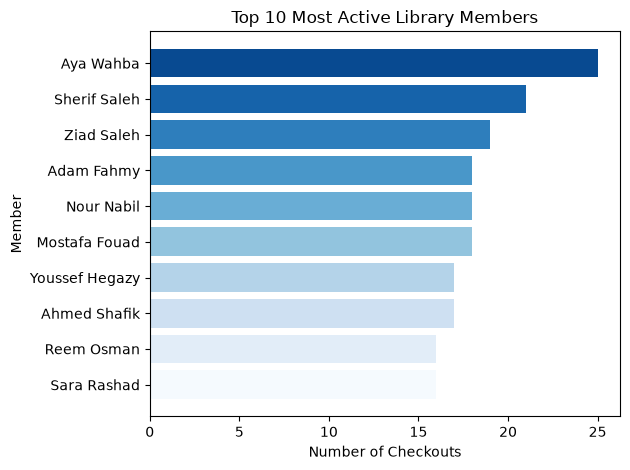

In [61]:
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(Top_active_members))
)
plt.barh(
    Top_active_members["full_name"],
    Top_active_members["borrow_count"],
    color=colors
)

plt.title("Top 10 Most Active Library Members")
plt.xlabel("Number of Checkouts")
plt.ylabel("Member")
plt.tight_layout()
plt.show()

##### How does borrowing behavior differ across grades, neighborhoods, and membership statuses?

##### by grade

In [62]:
borrowing_by_grade=(
    library_data
    .groupby("grade")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False))
borrowing_by_grade

,grade,borrow_count
2,8,118
3,9,113
0,6,91
1,7,90


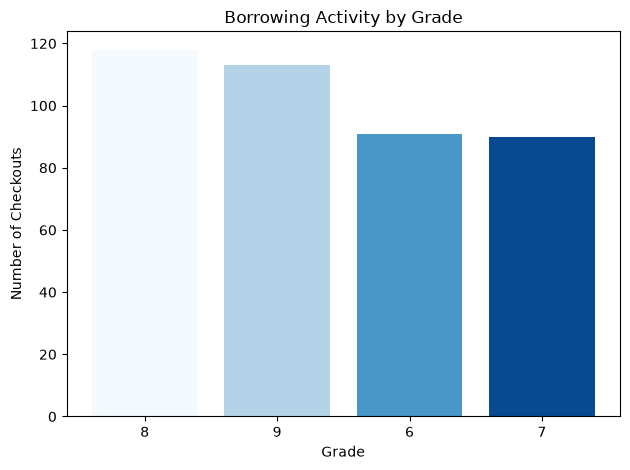

In [63]:
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(borrowing_by_grade))
)
plt.bar(
    borrowing_by_grade["grade"].astype(str),
    borrowing_by_grade["borrow_count"],
    color=colors
)

plt.title("Borrowing Activity by Grade")
plt.xlabel("Grade")
plt.ylabel("Number of Checkouts")
plt.tight_layout()
plt.show()

##### by neighborhood

In [64]:
borrowing_by_neighborhood = (
    library_data
    .groupby("neighborhood")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)

borrowing_by_neighborhood

,neighborhood,borrow_count
1,Maadi,115
2,Nasr City,104
0,Heliopolis,89
4,Zamalek,70
3,Shubra,34


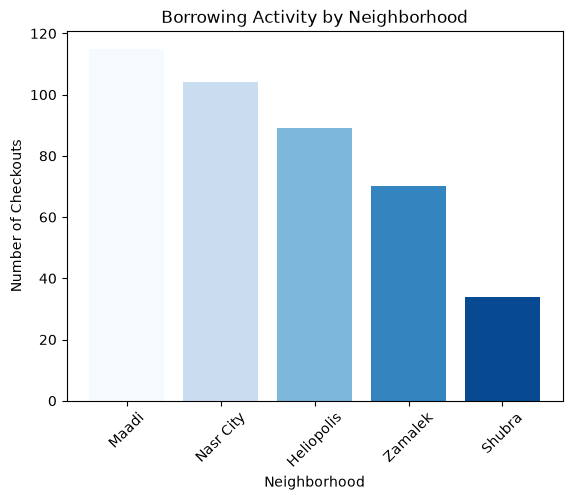

In [65]:
colors = plt.cm.Blues(
    np.linspace(0.01, 0.9, len(borrowing_by_neighborhood))
)
plt.bar(
    borrowing_by_neighborhood["neighborhood"],
    borrowing_by_neighborhood["borrow_count"],
    color=colors
)

plt.title("Borrowing Activity by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Checkouts")
plt.xticks(rotation=45)
plt.show()

##### my membership status

In [66]:
borrowing_by_status = (
    library_data
    .groupby("membership_status")
    .size()
    .reset_index(name="borrow_count")
    .sort_values("borrow_count", ascending=False)
)

borrowing_by_status

,membership_status,borrow_count
0,Active,325
1,Inactive,87


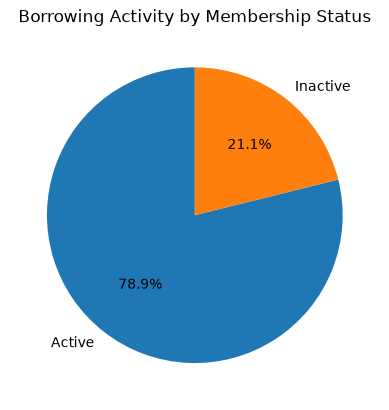

In [67]:
plt.pie(
    borrowing_by_status["borrow_count"],
    labels=borrowing_by_status["membership_status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Borrowing Activity by Membership Status")
plt.show()